<a href="https://colab.research.google.com/github/apple-pie-h/FDS-LAB-Works/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 8: Apply logistic regression and evaluate the model using metrics such as accuracy, precision, recall, and the ROC curve

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
confusion_matrix,
roc_curve,
auc,
classification_report,
)
# Generate synthetic data for binary classification
np.random.seed(42)
X = np.random.rand(200, 2) * 10 # 2 features
y = (4 * X[:, 0] - 3 * X[:, 1] + np.random.randn(200) > 0).astype(int) # Binary target
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Build and train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
# Predict on the test set
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1] # Probabilities for the positive class
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.98
Precision: 0.97
Recall: 1.00


In [3]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.98
Precision: 0.97
Recall: 1.00


In [4]:
# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.97      1.00      0.99        38

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix:
 [[21  1]
 [ 0 38]]


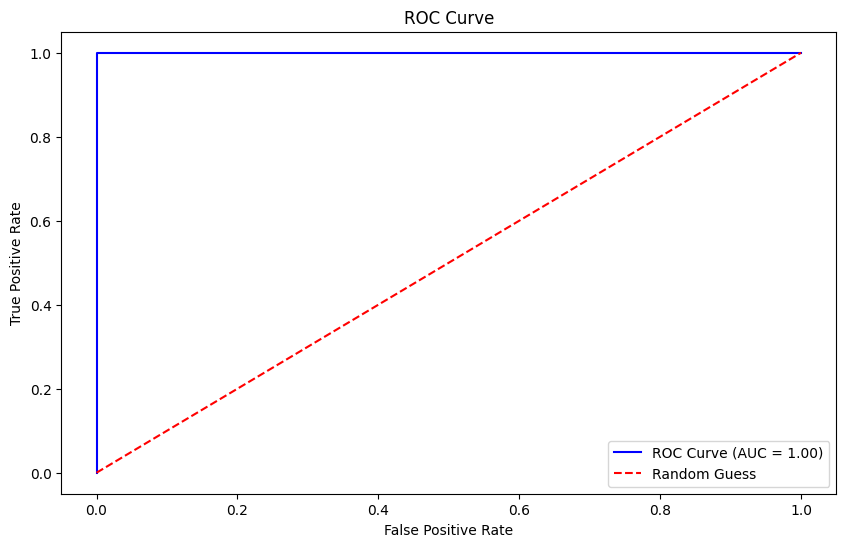

In [5]:
# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob) # False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()